In [1]:
# Instalar diversitree si no está instalado
if (!requireNamespace("diversitree", quietly = TRUE)) {
    install.packages("diversitree")
}

# Cargar las librerías necesarias
library(tidyverse)
library(phytools)
library(ggplot2)
library(taxize)
library(geiger)
library(diversitree)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v ggplot2   3.5.1     v tibble    3.2.1
v lubridate 1.9.3     v tidyr     1.3.1
v purrr     1.0.2     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Cargando paquete requerido: ape


Adjuntando el paquete: 'ape'


The following object is masked from 'package:dplyr':

    where


Cargando paquete requerido: maps


Adjuntando el paquete: 'maps'


The following object is masked from 'package:purrr':

    map



Adjuntando el paquete: 'diversitree'


The following object is masked from 'package:dplyr':

    combine




In [2]:
data <- read.csv("../src/data/data_tabular/data_songs_avonet_mean.csv", row.names = 1)
head(data)

,Genero,Familia,Suborder,Habitat,Habitat.Density,Migration,Trophic.Level,Trophic.Niche,Primary.Lifestyle,track_index,...,Beak.Depth,Tarsus.Length,Hand.Wing.Index,Tail.Length,Mass,Min.Latitude,Max.Latitude,Centroid.Latitude,Centroid.Longitude,Range.Size
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Acropternis_orthonyx,Acropternis,Rhinocryptidae,Tyranni,Forest,1,1,Carnivore,Invertivore,Insessorial,278392.9,...,6.5,36.4,5.5,88.9,89.86,-5.46,9.74,1.60,-76.74,112912.0
Agriornis_albicauda,Agriornis,Tyrannidae,Tyranni,Shrubland,3,1,Carnivore,Vertivore,Insessorial,346731.7,...,8.6,39.7,24.9,113.1,53.00,-27.47,0.00,-15.22,-71.16,579914.1
Agriornis_montanus,Agriornis,Tyrannidae,Tyranni,Shrubland,3,1,Carnivore,Omnivore,Insessorial,297753.2,...,5.7,33.1,25.1,98.2,63.30,-50.11,2.51,-30.52,-68.63,2168659.6
Alopochelidon_fucata,Alopochelidon,Hirundinidae,Passeri,Grassland,3,3,Carnivore,Invertivore,Aerial,510177.4,...,2.3,11.0,49.9,43.6,13.96,-36.66,10.63,-23.48,-56.90,4295655.0
Amblycercus_holosericeus,Amblycercus,Icteridae,Passeri,Forest,1,1,Carnivore,Invertivore,Insessorial,316182.1,...,9.8,31.5,10.6,97.5,70.42,-18.35,23.75,9.78,-84.39,1152587.0
Ammodramus_aurifrons,Ammodramus,Passerellidae,Passeri,Shrubland,3,1,Herbivore,Granivore,Terrestrial,346741.8,...,5.4,21.7,9.7,47.0,17.80,-17.92,10.18,-3.98,-66.53,3867543.9


In [3]:
tree <- read.nexus("../data/Stage2_MayrAll_Ericson_set10_decisive.nex")
tree


Phylogenetic tree with 9993 tips and 9992 internal nodes.

Tip labels:
  Nothura_maculosa, Nothura_minor, Nothura_darwinii, Nothura_boraquira, Nothura_chacoensis, Nothoprocta_taczanowskii, ...

Rooted; includes branch lengths.

In [4]:
labels <- tree$tip.label
labels_data <- rownames(data)

In [5]:
labels_not_in_tree <- labels_data[!labels_data %in% labels]
labels_in_tree <- labels_data[labels_data %in% labels]

In [6]:
pruned_tree <- keep.tip(tree, labels_in_tree)
pruned_tree


Phylogenetic tree with 904 tips and 903 internal nodes.

Tip labels:
  Sapayoa_aenigma, Phoenicircus_nigricollis, Rupicola_rupicola, Rupicola_peruvianus, Cotinga_cayana, Xipholena_punicea, ...

Rooted; includes branch lengths.

In [7]:
data <- data %>% filter(rownames(data) %in% labels_in_tree)

In [8]:
#eliminar colimnas
data_pca = subset(
    data, select = -which(names(data) %in% c(
        "Genero", "Familia", "Suborder", "Habitat", "Habitat.Density", "Migration", "Trophic.Level", "Trophic.Niche", "Primary.Lifestyle", 'chroma_cens_kurtosis_10','chroma_cens_kurtosis_11','chroma_cens_kurtosis_12','chroma_cens_skew_10','chroma_cens_skew_11','chroma_cens_skew_12', "track_index"
        )
    )
)

In [9]:
birds_pca = phyl.pca(pruned_tree, data_pca, method="BM", mode="corr")
pca.data = scores(birds_pca)
pca.data <- pca.data[,1:3]
head(pca.data)

,PC1,PC2,PC3
Acropternis_orthonyx,19.833118,-4.1377168,39.093535
Agriornis_albicauda,10.867942,-13.0969537,17.404771
Agriornis_montanus,20.192413,-19.6532326,40.807215
Alopochelidon_fucata,2.685530,-6.6586997,8.133309
Amblycercus_holosericeus,-2.123021,-7.6700664,-1.747892
Ammodramus_aurifrons,-6.493193,-0.5898166,-7.401447


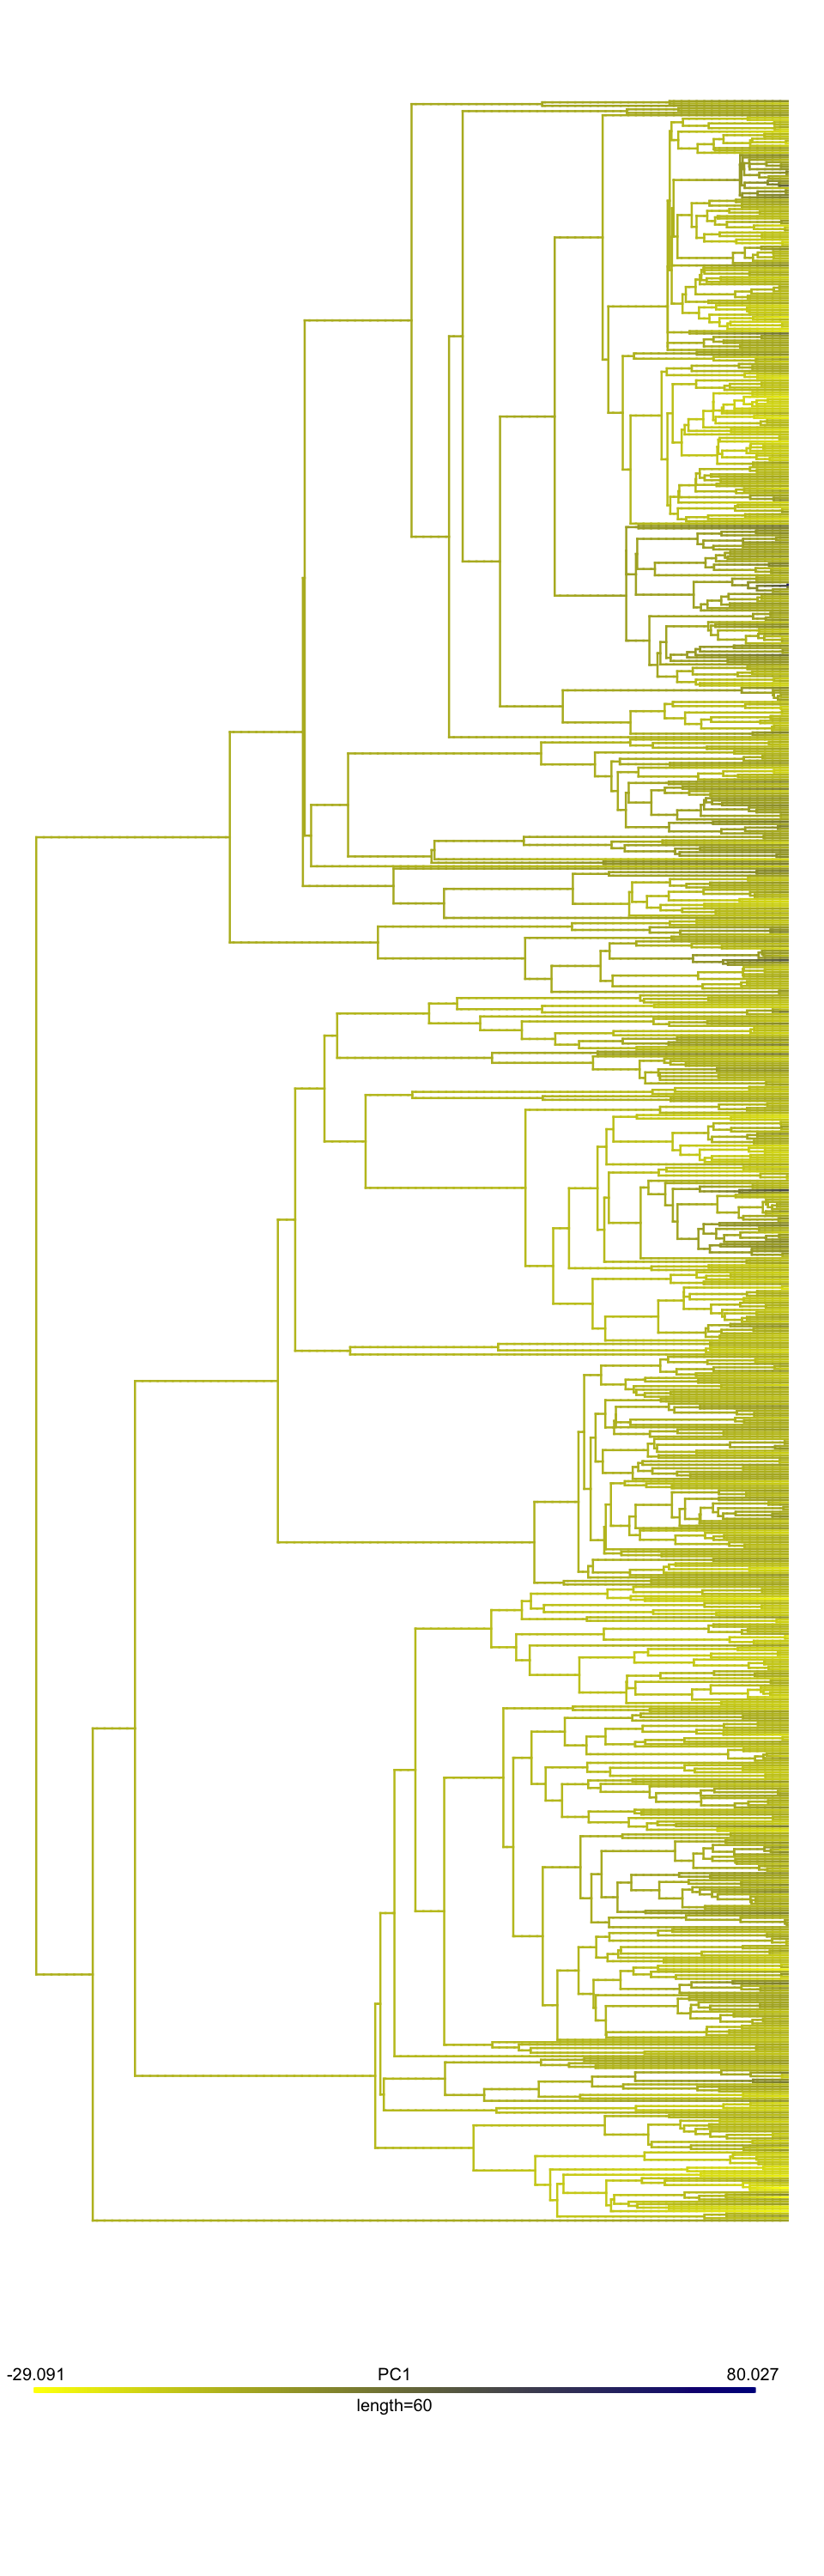

In [10]:
options(repr.plot.width = 8, repr.plot.height = 25)
par(bg = "white")
PC1<-setNames(pca.data[,"PC1"], rownames(pca.data))
pc1.map<-contMap(pruned_tree, PC1, plot=FALSE)
pc1.map<-setMap(pc1.map,c("yellow","darkblue"))
plot(pc1.map,lwd=c(2,5),outline=FALSE,ftype="off",leg.txt="PC1",legend=60)


In [11]:
rho<-Ntip(pruned_tree)/904
rho

[1] 1

In [12]:
bd<-fit.bd(pruned_tree,rho=rho)
bm<-fitContinuous(pruned_tree,PC1)
p<-setNames(c(bd$b,bd$d,bm$opt$sigsq),
c("lambda","mu","diffusion"))
p

Warning message in nlminb(c(init.b, init.d), lik.bd, t = T, rho = rho, lower = rep(0, :
"NA/NaN function evaluation"


lambda          mu   diffusion 
  0.1124152   0.0000000 422.7665453

In [13]:
PC1_S <- scale(PC1)

In [14]:
## define range of x
xr<-range(PC1_S)+c(-1,1)*20*p["diffusion"]
## make linear model for QuaSSE
linear.x<-make.linear.x(xr[1],xr[2])
linear.x

function (x, c, m) 
{
    x[x < x0] <- x0
    x[x > x1] <- x1
    ans <- m * x + c
    ans[ans < 0] <- 0
    ans
}
<bytecode: 0x17ffc3578>
<environment: 0x17ffc2468>

In [16]:
## make QuaSSE likelihood function for variable
## lambda and constrain
lik.lambda<-make.quasse(pruned_tree,PC1,lambda=linear.x,mu=constant.x,
sampling.f=rho,states.sd=0.1)
lik.lambda<-constrain(lik.lambda,drift~0)
lik.lambda

QuaSSE likelihood function:
  * Parameter vector takes 4 elements:
     - l.c, l.m, m.c, diffusion
  * Function constrained (original took 5 elements):
     - drift ~ 0
  * Function takes arguments (with defaults)
     - pars: Parameter vector
     - ...: Additional arguments to underlying function
     - pars.only [FALSE]: Return full parameter vector?
  * Phylogeny with 904 tips and 903 nodes
     - Taxa: Sapayoa_aenigma, Phoenicircus_nigricollis, ...
  * Reference:
     - FitzJohn (2010) doi:10.1093/sysbio/syq053
R definition:
function (pars, ..., pars.only = FALSE)

In [17]:
## subsample starting parameter values to match
## the model we’re fitting
pp<-setNames(c(p["lambda"],0,p["mu"],p["diffusion"]),argnames(lik.lambda))
pp

l.c         l.m         m.c   diffusion 
  0.1124152   0.0000000   0.0000000 422.7665453

In [18]:
## fit our first QuaSSE model
lambda.mle <- find.mle(lik.lambda,x.init=pp, control=list(parscale=0.1),lower=rep(0,4))
lambda.mle

$par
         l.c          l.m          m.c    diffusion 
1.162920e-01 1.279429e-03 1.371086e-04 4.227468e+02 

$lnLik
[1] -7462.693

$counts
[1] 141

$convergence
[1] 0

$message
[1] "success! tolerance satisfied"

$hessian
NULL

$method
[1] "subplex"

$par.full
         l.c          l.m          m.c        drift    diffusion 
1.162920e-01 1.279429e-03 1.371086e-04 0.000000e+00 4.227468e+02 

$func.class
[1] "constrained" "quasse"      "dtlik"       "function"   

attr(,"func")
QuaSSE likelihood function:
  * Parameter vector takes 4 elements:
     - l.c, l.m, m.c, diffusion
  * Function constrained (original took 5 elements):
     - drift ~ 0
  * Function takes arguments (with defaults)
     - pars: Parameter vector
     - ...: Additional arguments to underlying function
     - pars.only [FALSE]: Return full parameter vector?
  * Phylogeny with 904 tips and 903 nodes
     - Taxa: Sapayoa_aenigma, Phoenicircus_nigricollis, ...
  * Reference:
     - FitzJohn (2010) doi:10.1093/sysbio/s

In [ ]:
## make QuaSSE likelihood function for variable
## mu and constrain
lik.mu <- make.quasse(
        pruned_tree,
        PC1,
        lambda=constant.x,
        mu=linear.x,
        sampling.f=rho,
        states.sd=0.1
        )

lik.mu<-constrain(lik.mu, drift~0)
## fit variable mu model
pp<-setNames(c(p[c("lambda", "mu")],0, p["diffusion"]), argnames(lik.mu))
mu.mle<-find.mle(lik.mu, x.init=pp, control=list(parscale=0.1), lower=rep(0,4))

In [20]:
coef(mu.mle)

l.c          m.c          m.m    diffusion 
1.317268e-01 5.264956e-05 2.213536e-03 4.228171e+02

In [21]:
logLik(mu.mle)

'log Lik.' -7410.456 (df=4)

In [ ]:
# Recrear el modelo con parámetros de control más conservadores
lik.full <- make.quasse(
    pruned_tree,
    PC1,
    lambda=linear.x,
    mu=linear.x,
    sampling.f=rho,
    states.sd=0.1
)
lik.full <- constrain(lik.full, drift~0)
## fit full QuaSSE model
pp<-setNames(c(lambda.mle$par[1:2], mu.mle$par[2:3], p["diffusion"]),argnames(lik.full))
pp

l.c          l.m          m.c          m.m    diffusion 
1.162920e-01 1.279429e-03 5.264956e-05 2.213536e-03 4.227665e+02

In [ ]:
## likelihood function for character-
## independent model
lik.cid<-make.quasse(pruned_tree, PC1, lambda=constant.x, mu=constant.x,sampling.f=rho,states.sd=0.1)
lik.cid<-constrain(lik.cid,drift~0)
argnames(lik.cid)

In [ ]:
## fit CID QuaSSE model and print coefficients
cid.mle<-find.mle(lik.cid,x.init=p, control=list(parscale=0.1),lower=rep(0,3))
coef(cid.mle)

In [ ]:
logLik(cid.mle)

In [ ]:
# COMPARACIÓN ESTADÍSTICA DE MODELOS
# Realizar ANOVA solo con los modelos que funcionaron

print("=== COMPARACIÓN ESTADÍSTICA DE MODELOS ===")

if (!is.null(full.mle)) {
    # Si el modelo completo funciona, hacer el ANOVA completo
    print("Realizando ANOVA completo con todos los modelos:")
    anova_result <- anova(cid.mle, variable.lambda=lambda.mle, variable.mu=mu.mle, full.model=full.mle)
    print(anova_result)
} else {
    # Si el modelo completo falla, comparar solo los modelos simples
    print("Modelo completo no disponible. Comparando modelos simples:")

    # Comparación manual usando likelihood ratio tests
    # CID vs Variable Lambda
    lr_cid_lambda <- 2 * (logLik(lambda.mle) - logLik(cid.mle))
    df_cid_lambda <- length(coef(lambda.mle)) - length(coef(cid.mle))
    p_cid_lambda <- pchisq(lr_cid_lambda, df_cid_lambda, lower.tail = FALSE)

    # CID vs Variable Mu
    lr_cid_mu <- 2 * (logLik(mu.mle) - logLik(cid.mle))
    df_cid_mu <- length(coef(mu.mle)) - length(coef(cid.mle))
    p_cid_mu <- pchisq(lr_cid_mu, df_cid_mu, lower.tail = FALSE)

    # Lambda vs Mu
    lr_lambda_mu <- 2 * (logLik(mu.mle) - logLik(lambda.mle))
    df_lambda_mu <- length(coef(mu.mle)) - length(coef(lambda.mle))
    p_lambda_mu <- pchisq(abs(lr_lambda_mu), abs(df_lambda_mu), lower.tail = FALSE)

    # Crear tabla de resultados
    comparison_table <- data.frame(
        Comparison = c("CID vs Variable Lambda", "CID vs Variable Mu", "Variable Lambda vs Variable Mu"),
        LR_statistic = c(lr_cid_lambda, lr_cid_mu, lr_lambda_mu),
        df = c(df_cid_lambda, df_cid_mu, df_lambda_mu),
        p_value = c(p_cid_lambda, p_cid_mu, p_lambda_mu),
        Significant = c(p_cid_lambda < 0.05, p_cid_mu < 0.05, p_lambda_mu < 0.05)
    )

    print(comparison_table)

    # Interpretación
    print("\n--- INTERPRETACIÓN ---")
    if (p_cid_lambda < 0.05) {
        print("✓ Variable Lambda es significativamente mejor que CID")
    } else {
        print("✗ Variable Lambda no es significativamente mejor que CID")
    }

    if (p_cid_mu < 0.05) {
        print("✓ Variable Mu es significativamente mejor que CID")
    } else {
        print("✗ Variable Mu no es significativamente mejor que CID")
    }

    if (p_lambda_mu < 0.05) {
        if (lr_lambda_mu > 0) {
            print("✓ Variable Mu es significativamente mejor que Variable Lambda")
        } else {
            print("✓ Variable Lambda es significativamente mejor que Variable Mu")
        }
    } else {
        print("≈ Variable Lambda y Variable Mu no difieren significativamente")
    }

    # Usar comparación de modelos simple como alternativa
    print("\n--- COMPARACIÓN POR AIC ---")
    simple_anova <- anova(cid.mle, variable.lambda=lambda.mle, variable.mu=mu.mle)
    print(simple_anova)
}

In [ ]:
## subdivide plotting area
par(mfrow=c(2,2))
## a) plot constant rate (CID) QuaSSE model
plot(NULL,xlim=range(PC1),ylim=c(0,1.5),bty="n", xlab="PC1", ylab=expression(paste(lambda," or ",mu)))
mtext("(a)",line=1,adj=0)
clip(min(PC1),max(PC1),0,1.5)
abline(h=cid.mle$par["lambda"],lwd=2)
abline(h=cid.mle$par["mu"],lwd=2,col="gray")
## b) plot variable lambda QuaSSE model
plot(NULL,xlim=range(PC1),ylim=c(0,1.5),bty="n", xlab="PC1", ylab=expression(paste(lambda," or ",mu)))
mtext("(b)",line=1,adj=0)
clip(min(PC1),max(PC1),0,1.5)
abline(a=coef(lambda.mle)["l.c"], b=coef(lambda.mle)["l.m"],lwd=2)
abline(h=coef(lambda.mle)["m.c"],lwd=2, col="gray")
legend(x=3,y=1.5, c(expression(lambda),expression(mu)),lwd=2,col=c("black","gray"),bty="n")
## c) plot variable mu QuaSSE model
plot(NULL,xlim=range(PC1),ylim=c(0,1.5),bty="n", xlab="PC1", ylab=expression(paste(lambda," or ",mu)))
mtext("(c)",line=1,adj=0)
clip(min(PC1),max(PC1),0,1.5)
abline(h=coef(mu.mle)["l.c"],lwd=2)
abline(a=coef(mu.mle)["m.c"], b=coef(mu.mle)["m.m"],lwd=2,col="gray")
## d) plot variable lambda and mu QuaSSE model
plot(NULL,xlim=range(PC1),ylim=c(0,1.5),bty="n", xlab="PC1", ylab=expression(paste(lambda," or ",mu)))
mtext("(d)",line=1,adj=0)
clip(min(PC1),max(PC1),0,1.5)
abline(a=coef(full.mle)["l.c"], b=coef(full.mle)["l.m"],lwd=2)
abline(a=coef(full.mle)["m.c"], b=coef(full.mle)["m.m"],lwd=2,col="gray")